# 📊 Linear Regression Tutorial for Turbofan Engine RUL Prediction

## Learning Objectives

By the end of this tutorial, you will:
- Understand what Linear Regression is and how it works
- Learn how to prepare data for machine learning
- Understand features (X) and targets (y)
- Learn about loss functions (MSE, MAE) and why we use them
- Train your first machine learning model
- Evaluate model performance
- Visualize predictions vs actual values

---

## What is Linear Regression?

**Linear Regression** is one of the simplest and most fundamental machine learning algorithms.

### The Basic Idea:

Imagine you want to predict a student's test score based on how many hours they studied. Linear regression finds a **straight line** that best fits the data points.

### The Formula:

```
y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b
```

Where:
- **y**: What we want to predict (target) - in our case, RUL
- **x₁, x₂, ..., xₙ**: Features (inputs) - sensor readings, operational settings
- **w₁, w₂, ..., wₙ**: Weights (coefficients) - learned by the model
- **b**: Bias (intercept) - starting point

### How It Works:

1. **Training**: The model learns the best weights (w) and bias (b) by looking at examples
2. **Prediction**: Once trained, it uses the learned formula to predict new values

### Why Start with Linear Regression?
- **Simple**: Easy to understand and implement
- **Fast**: Trains quickly even on large datasets
- **Interpretable**: You can see what features are important
- **Baseline**: Good starting point before trying complex models

---

## Our Goal: Predict RUL (Remaining Useful Life)

We want to predict **how many cycles** an engine has left before it fails, based on:
- Sensor readings (temperature, pressure, speed, etc.)
- Operational settings (altitude, mach number, throttle)
- Time information

This is a **regression problem** because we're predicting a continuous number (not a category).

## Step 1: Import Required Libraries

Before we start, we need to import the necessary libraries.

### Libraries We'll Use:
- **pandas**: For DataFrames and data manipulation
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For visualizations
- **sklearn**: Scikit-learn - the main machine learning library
  - `LinearRegression`: Our linear regression model
  - `train_test_split`: To split data into training and validation sets
  - `mean_squared_error`, `mean_absolute_error`, `r2_score`: For evaluation metrics

In [1]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import machine learning components from scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.3.2
📦 NumPy version: 2.2.6
📦 Scikit-learn version: 1.7.2


## Step 2: Load the Dataset

Let's load our turbofan engine dataset. We'll use the CSV files we created earlier.

### Understanding the Data:
- **Training data**: Complete run-to-failure data (we know when engines failed)
- **Test data**: Partial trajectories (we need to predict RUL)
- **RUL**: Remaining Useful Life - our target variable

In [2]:
# Define the path to our dataset
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
           'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # Read CSV files (they already have headers)
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """
    Calculate RUL (Remaining Useful Life) for training data.
    
    RUL = Maximum time for that engine - Current time
    
    Example: If an engine runs for 200 cycles total, and we're at cycle 50,
    then RUL = 200 - 50 = 150 cycles remaining.
    """
    df = df.copy()
    # For each engine, calculate: max_time - current_time
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\n📊 Training data shape: {train_df.shape}")
print(f"   - Rows: {train_df.shape[0]:,}")
print(f"   - Columns: {train_df.shape[1]}")
print(f"\n📊 Test data shape: {test_df.shape}")
print(f"   - Rows: {test_df.shape[0]:,}")
print(f"   - Columns: {test_df.shape[1]}")
print(f"\n🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")
print(f"\n⏱️  RUL range in training: {train_df['RUL'].min()} to {train_df['RUL'].max()} cycles")

✅ Data loaded successfully!

📊 Training data shape: (20631, 27)
   - Rows: 20,631
   - Columns: 27

📊 Test data shape: (13096, 26)
   - Rows: 13,096
   - Columns: 26

🚁 Number of engines in training: 100
🚁 Number of engines in test: 100

⏱️  RUL range in training: 0 to 361 cycles


## Step 3: Understanding Features (X) and Target (y)

Before building a model, we need to understand the difference between:

### Features (X) - Input Variables:
- These are the **inputs** to our model
- What we use to make predictions
- Examples: sensor readings, operational settings, time
- Also called: **independent variables**, **predictors**, **X**

### Target (y) - What We Want to Predict:
- This is the **output** we want to predict
- In our case: **RUL** (Remaining Useful Life)
- Also called: **dependent variable**, **label**, **y**

### The Relationship:
```
y (RUL) = f(X) = f(sensors, settings, time, ...)
```

Our model learns the function **f** that maps features to RUL.

In [3]:
# Let's examine the data structure
print("📋 First few rows of training data:")
print("=" * 80)
train_df.head()

📋 First few rows of training data:


,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [7]:
# Check the RUL column (our target)
print("📊 RUL (Remaining Useful Life) Statistics:")
print("=" * 80)
print(train_df['RUL'].describe())

print("\n💡 Understanding RUL:")
print("   - RUL = 0 means the engine just failed")
print("   - Higher RUL means more cycles remaining")
print("   - We want to predict this value based on sensor readings")

📊 RUL (Remaining Useful Life) Statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

💡 Understanding RUL:
   - RUL = 0 means the engine just failed
   - Higher RUL means more cycles remaining
   - We want to predict this value based on sensor readings


## Step 4: Prepare Features (X) and Target (y)

Now we need to separate our data into:
- **X (Features)**: What we use to make predictions
- **y (Target)**: What we want to predict (RUL)

### What Features Should We Use?

We'll use:
1. **Operational Settings**: Altitude, Mach, TRA
2. **Sensor Readings**: All 21 sensors
3. **Time Information**: Current time cycle

We **exclude**:
- `unit`: Engine ID (not a feature for prediction)
- `RUL`: This is our target, not a feature!

In [8]:
# Select features (X) - everything except unit and RUL
# We include: operational settings, sensors, and time
feature_columns = op_settings + sensors + ['time']

# Prepare training features (X) and target (y)
X_train = train_df[feature_columns].copy()
y_train = train_df['RUL'].copy()

print("✅ Features and target prepared!")
print(f"\n📊 Training Features (X) shape: {X_train.shape}")
print(f"   - Number of samples: {X_train.shape[0]:,}")
print(f"   - Number of features: {X_train.shape[1]}")
print(f"\n📊 Target (y) shape: {y_train.shape}")
print(f"\n📝 Feature names:")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i:2d}. {col}")

✅ Features and target prepared!

📊 Training Features (X) shape: (20631, 25)
   - Number of samples: 20,631
   - Number of features: 25

📊 Target (y) shape: (20631,)

📝 Feature names:
    1. Altitude
    2. Mach
    3. TRA
    4. T2
    5. T24
    6. T30
    7. T50
    8. P2
    9. P15
   10. P30
   11. Nf
   12. Nc
   13. epr
   14. Ps30
   15. phi
   16. NRf
   17. NRc
   18. BPR
   19. farB
   20. htBleed
   21. Nf_dmd
   22. PCNfR_dmd
   23. W31
   24. W32
   25. time


In [9]:
# Display sample of features
print("📋 Sample of Features (X):")
print("=" * 80)
X_train.head()

📋 Sample of Features (X):


,Altitude,Mach,TRA,T2,T24,T30,T50,P2,P15,P30,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,time
0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,1
1,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,2
2,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,3
3,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,4
4,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,5


In [10]:
# Display sample of target
print("📋 Sample of Target (y = RUL):")
print("=" * 80)
print(y_train.head(10))
print(f"\n📊 Target statistics:")
print(f"   Min: {y_train.min()}")
print(f"   Max: {y_train.max()}")
print(f"   Mean: {y_train.mean():.2f}")
print(f"   Std: {y_train.std():.2f}")

📋 Sample of Target (y = RUL):
0    191
1    190
2    189
3    188
4    187
5    186
6    185
7    184
8    183
9    182
Name: RUL, dtype: int64

📊 Target statistics:
   Min: 0
   Max: 361
   Mean: 107.81
   Std: 68.88


## Step 5: Prepare Test Data

For test data, we need to:
1. Extract features (same as training)
2. Get the **last timestep** for each engine (most recent sensor readings)
3. Use the provided RUL values as ground truth

### Why Last Timestep?
- In real-world scenarios, we want to predict RUL based on the **current** state
- The last timestep represents the most recent sensor readings
- This is what we'd use in practice to predict remaining life

In [11]:
# Prepare test features
# We need only the LAST timestep for each engine

# Find the last row index for each engine
test_last_indices = test_df.groupby('unit')['time'].idxmax().values

# Get features for the last timestep of each engine
X_test = test_df.loc[test_last_indices, feature_columns].reset_index(drop=True)

# Get the actual RUL values (ground truth)
y_test = rul_df['RUL'].values

print("✅ Test data prepared!")
print(f"\n📊 Test Features (X_test) shape: {X_test.shape}")
print(f"   - Number of engines: {X_test.shape[0]}")
print(f"   - Number of features: {X_test.shape[1]}")
print(f"\n📊 Test Target (y_test) shape: {y_test.shape}")
print(f"\n⏱️  RUL range in test: {y_test.min()} to {y_test.max()} cycles")
print(f"   Mean RUL: {y_test.mean():.2f} cycles")

✅ Test data prepared!

📊 Test Features (X_test) shape: (100, 25)
   - Number of engines: 100
   - Number of features: 25

📊 Test Target (y_test) shape: (100,)

⏱️  RUL range in test: 7 to 145 cycles
   Mean RUL: 75.52 cycles


## Step 6: Data Normalization/Scaling

### Why Scale the Data?

Different features have very different scales:
- Temperature might be: 500-1600
- Pressure might be: 10-600
- Time might be: 1-300

### The Problem:
Linear regression works better when all features are on a similar scale. Without scaling:
- Features with larger values dominate
- The model might not learn properly
- Training can be slow or unstable

### The Solution: Standardization

We'll use **StandardScaler** which:
- Centers the data (mean = 0)
- Scales to unit variance (std = 1)

Formula: `(x - mean) / std`

### Important:
- **Fit** the scaler on training data only
- **Transform** both training and test data
- Never fit on test data! (This would be data leakage)

In [12]:
# Create a scaler for features
# StandardScaler: (x - mean) / std
scaler_X = StandardScaler()

# Fit the scaler on TRAINING data only
# This calculates mean and std from training data
X_train_scaled = scaler_X.fit_transform(X_train)

# Transform test data using the SAME scaler (same mean and std)
# Important: We don't fit on test data!
X_test_scaled = scaler_X.transform(X_test)

print("✅ Data scaled successfully!")
print(f"\n📊 Before scaling (sample of first feature - Altitude):")
print(f"   Min: {X_train['Altitude'].min():.4f}")
print(f"   Max: {X_train['Altitude'].max():.4f}")
print(f"   Mean: {X_train['Altitude'].mean():.4f}")
print(f"   Std: {X_train['Altitude'].std():.4f}")

print(f"\n📊 After scaling (sample of first feature):")
print(f"   Min: {X_train_scaled[:, 0].min():.4f}")
print(f"   Max: {X_train_scaled[:, 0].max():.4f}")
print(f"   Mean: {X_train_scaled[:, 0].mean():.4f}")
print(f"   Std: {X_train_scaled[:, 0].std():.4f}")

print("\n💡 Notice: After scaling, mean ≈ 0 and std ≈ 1")

✅ Data scaled successfully!

📊 Before scaling (sample of first feature - Altitude):
   Min: -0.0087
   Max: 0.0087
   Mean: -0.0000
   Std: 0.0022

📊 After scaling (sample of first feature):
   Min: -3.9735
   Max: 3.9816
   Mean: 0.0000
   Std: 1.0000

💡 Notice: After scaling, mean ≈ 0 and std ≈ 1


## Step 7: Split Training Data into Train and Validation Sets

### Why Split the Data?

We need to:
1. **Train** the model on some data
2. **Validate** the model on different data (to check if it's learning)
3. **Test** the model on completely unseen data (final evaluation)

### The Split:
- **Training Set (80%)**: Used to train the model
- **Validation Set (20%)**: Used to check performance during training
- **Test Set**: Already separate - used for final evaluation

### Why Not Use All Training Data?
- We need to see if the model **generalizes** (works on new data)
- If we only check on data the model saw, we might **overfit**
- Validation set helps us tune the model

In [13]:
# Split training data into train and validation sets
# test_size=0.2 means 20% goes to validation, 80% stays for training
# random_state=42 ensures we get the same split every time (for reproducibility)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, 
    random_state=42
)

print("✅ Data split successfully!")
print(f"\n📊 Training set (for model training):")
print(f"   - Features shape: {X_train_split.shape}")
print(f"   - Target shape: {y_train_split.shape}")
print(f"   - Percentage: {len(X_train_split) / len(X_train_scaled) * 100:.1f}%")

print(f"\n📊 Validation set (for checking performance):")
print(f"   - Features shape: {X_val_split.shape}")
print(f"   - Target shape: {y_val_split.shape}")
print(f"   - Percentage: {len(X_val_split) / len(X_train_scaled) * 100:.1f}%")

print(f"\n📊 Test set (for final evaluation):")
print(f"   - Features shape: {X_test_scaled.shape}")
print(f"   - Target shape: {y_test.shape}")

✅ Data split successfully!

📊 Training set (for model training):
   - Features shape: (16504, 25)
   - Target shape: (16504,)
   - Percentage: 80.0%

📊 Validation set (for checking performance):
   - Features shape: (4127, 25)
   - Target shape: (4127,)
   - Percentage: 20.0%

📊 Test set (for final evaluation):
   - Features shape: (100, 25)
   - Target shape: (100,)


## Step 8: Understanding Loss Functions

### What is a Loss Function?

A **loss function** (also called **cost function** or **error function**) measures how **wrong** our predictions are.

### Why Do We Need It?

The model uses the loss function to:
1. **Measure error**: How far off are our predictions?
2. **Learn**: Adjust weights to minimize the loss
3. **Improve**: Lower loss = better predictions

### Common Loss Functions for Regression:

#### 1. Mean Squared Error (MSE)

**Formula**: `MSE = (1/n) × Σ(actual - predicted)²`

**Characteristics**:
- Squares the errors (makes large errors much worse)
- Always positive
- Units: squared units (e.g., cycles²)
- **Penalizes large errors heavily**

**Example**:
- Actual: 100, Predicted: 90 → Error: 10 → Squared: 100
- Actual: 100, Predicted: 50 → Error: 50 → Squared: 2500

#### 2. Mean Absolute Error (MAE)

**Formula**: `MAE = (1/n) × Σ|actual - predicted|`

**Characteristics**:
- Takes absolute value of errors
- Always positive
- Units: same as target (e.g., cycles)
- **Treats all errors equally**

**Example**:
- Actual: 100, Predicted: 90 → Error: |10| = 10
- Actual: 100, Predicted: 50 → Error: |50| = 50

#### 3. Root Mean Squared Error (RMSE)

**Formula**: `RMSE = √MSE`

**Characteristics**:
- Square root of MSE
- Same units as target (easier to interpret)
- Also penalizes large errors

### Which One to Use?

- **MSE/RMSE**: When large errors are very bad (safety-critical)
- **MAE**: When all errors are equally important
- **For RUL prediction**: We often use both to understand different aspects

### How Linear Regression Uses Loss:

Linear regression **minimizes MSE** by default. It finds weights that make the sum of squared errors as small as possible.

In [14]:
# Let's demonstrate loss functions with a simple example

# Example predictions and actual values
actual = np.array([100, 150, 200, 250, 300])
predicted = np.array([95, 155, 195, 260, 290])

# Calculate errors
errors = actual - predicted

print("📊 Loss Function Example:")
print("=" * 80)
print(f"Actual values:    {actual}")
print(f"Predicted values: {predicted}")
print(f"Errors:           {errors}")

# Calculate MSE
mse = mean_squared_error(actual, predicted)
print(f"\n📈 Mean Squared Error (MSE): {mse:.2f}")
print(f"   Formula: (1/n) × Σ(actual - predicted)²")
print(f"   Calculation: {np.mean(errors**2):.2f}")

# Calculate MAE
mae = mean_absolute_error(actual, predicted)
print(f"\n📈 Mean Absolute Error (MAE): {mae:.2f}")
print(f"   Formula: (1/n) × Σ|actual - predicted|")
print(f"   Calculation: {np.mean(np.abs(errors)):.2f}")

# Calculate RMSE
rmse = np.sqrt(mse)
print(f"\n📈 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"   Formula: √MSE")
print(f"   Calculation: √{mse:.2f} = {rmse:.2f}")

print("\n💡 Notice:")
print("   - MSE is in squared units (cycles²)")
print("   - MAE and RMSE are in original units (cycles)")
print("   - RMSE is always ≥ MAE (because of squaring)")

📊 Loss Function Example:
Actual values:    [100 150 200 250 300]
Predicted values: [ 95 155 195 260 290]
Errors:           [  5  -5   5 -10  10]

📈 Mean Squared Error (MSE): 55.00
   Formula: (1/n) × Σ(actual - predicted)²
   Calculation: 55.00

📈 Mean Absolute Error (MAE): 7.00
   Formula: (1/n) × Σ|actual - predicted|
   Calculation: 7.00

📈 Root Mean Squared Error (RMSE): 7.42
   Formula: √MSE
   Calculation: √55.00 = 7.42

💡 Notice:
   - MSE is in squared units (cycles²)
   - MAE and RMSE are in original units (cycles)
   - RMSE is always ≥ MAE (because of squaring)


## Step 9: Create and Train the Linear Regression Model

Now we'll create our linear regression model and train it!

### What Happens During Training?

1. **Initialize**: Start with random weights
2. **Predict**: Make predictions using current weights
3. **Calculate Loss**: Measure how wrong predictions are (using MSE)
4. **Update Weights**: Adjust weights to reduce loss
5. **Repeat**: Keep improving until loss is minimized

### Linear Regression in Scikit-Learn:

Scikit-learn's `LinearRegression`:
- Uses **Ordinary Least Squares (OLS)** method
- Minimizes **MSE** automatically
- Finds the best weights mathematically (no iteration needed!)
- Very fast and efficient

In [15]:
# Create a Linear Regression model
# This model will learn: y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b
model = LinearRegression()

print("✅ Linear Regression model created!")
print("\n📝 Model details:")
print(f"   - Algorithm: Ordinary Least Squares (OLS)")
print(f"   - Loss function: Mean Squared Error (MSE)")
print(f"   - Number of features: {X_train_split.shape[1]}")
print(f"   - Training samples: {X_train_split.shape[0]:,}")

✅ Linear Regression model created!

📝 Model details:
   - Algorithm: Ordinary Least Squares (OLS)
   - Loss function: Mean Squared Error (MSE)
   - Number of features: 25
   - Training samples: 16,504


In [16]:
# Train the model!
# This is where the magic happens - the model learns from data
print("🚀 Training the model...")
print("=" * 80)

# Fit the model to training data
# This finds the best weights (w) and bias (b) that minimize MSE
model.fit(X_train_split, y_train_split)

print("✅ Model trained successfully!")

# The model now has learned:
# - Coefficients (weights) for each feature
# - Intercept (bias)

print(f"\n📊 Model learned:")
print(f"   - Number of coefficients (weights): {len(model.coef_)}")
print(f"   - Intercept (bias): {model.intercept_:.4f}")
print(f"\n💡 The model equation is now:")
print(f"   RUL = {model.intercept_:.2f} + ", end="")
print(f"{model.coef_[0]:.4f}×Altitude + {model.coef_[1]:.4f}×Mach + ... + {model.coef_[-1]:.4f}×time")

🚀 Training the model...
✅ Model trained successfully!

📊 Model learned:
   - Number of coefficients (weights): 25
   - Intercept (bias): 108.0316

💡 The model equation is now:
   RUL = 108.03 + -0.0271×Altitude + 0.9018×Mach + ... + -27.2273×time


In [17]:
# Let's see which features are most important
# Larger absolute coefficient = more important feature

# Create a DataFrame to show feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("📊 Top 10 Most Important Features (by absolute coefficient):")
print("=" * 80)
print(feature_importance.head(10).to_string(index=False))

print("\n💡 Interpretation:")
print("   - Positive coefficient: As feature increases, RUL increases")
print("   - Negative coefficient: As feature increases, RUL decreases")
print("   - Larger absolute value = stronger influence on RUL")

📊 Top 10 Most Important Features (by absolute coefficient):
Feature  Coefficient  Abs_Coefficient
   time   -27.227271        27.227271
   Ps30    -5.766399         5.766399
     Nc    -4.949552         4.949552
    phi     4.784167         4.784167
    P30     4.230157         4.230157
    T50    -3.887442         3.887442
    T24    -2.860313         2.860313
    W32     2.535684         2.535684
    BPR    -2.364308         2.364308
    W31     2.183014         2.183014

💡 Interpretation:
   - Positive coefficient: As feature increases, RUL increases
   - Negative coefficient: As feature increases, RUL decreases
   - Larger absolute value = stronger influence on RUL


## Step 10: Make Predictions

Now that the model is trained, we can use it to make predictions!

### How Predictions Work:

The model uses the learned formula:
```
predicted_RUL = intercept + (coef₁ × feature₁) + (coef₂ × feature₂) + ...
```

We'll make predictions on:
1. **Training set**: To see how well it learned
2. **Validation set**: To check generalization
3. **Test set**: Final evaluation on unseen data

In [18]:
# Make predictions on all datasets

# Training set predictions
y_train_pred = model.predict(X_train_split)

# Validation set predictions
y_val_pred = model.predict(X_val_split)

# Test set predictions
y_test_pred = model.predict(X_test_scaled)

print("✅ Predictions made successfully!")
print(f"\n📊 Prediction shapes:")
print(f"   Training predictions: {y_train_pred.shape}")
print(f"   Validation predictions: {y_val_pred.shape}")
print(f"   Test predictions: {y_test_pred.shape}")

print(f"\n📊 Sample predictions (first 5):")
print(f"   Actual RUL:    {y_test[:5]}")
print(f"   Predicted RUL: {y_test_pred[:5].round(2)}")
print(f"   Errors:        {(y_test[:5] - y_test_pred[:5]).round(2)}")

✅ Predictions made successfully!

📊 Prediction shapes:
   Training predictions: (16504,)
   Validation predictions: (4127,)
   Test predictions: (100,)

📊 Sample predictions (first 5):
   Actual RUL:    [112  98  69  82  91]
   Predicted RUL: [169.71 139.14  85.05 102.51 111.9 ]
   Errors:        [-57.71 -41.14 -16.05 -20.51 -20.9 ]


## Step 11: Evaluate Model Performance

Now let's measure how good our model is using different metrics.

### Evaluation Metrics:

1. **RMSE (Root Mean Squared Error)**: Average prediction error (in cycles)
   - Lower is better
   - Penalizes large errors

2. **MAE (Mean Absolute Error)**: Average absolute error (in cycles)
   - Lower is better
   - Easier to interpret

3. **R² Score (Coefficient of Determination)**: How well the model fits
   - Range: -∞ to 1
   - **1.0**: Perfect predictions
   - **0.0**: Model is as good as just predicting the mean
   - **Negative**: Model is worse than predicting the mean
   - Higher is better

### What to Look For:
- **Training vs Validation**: Similar scores = good generalization
- **Large gap**: Model might be overfitting
- **Test performance**: Final measure of how well it works on new data

In [19]:
# Calculate metrics for training set
train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
train_mae = mean_absolute_error(y_train_split, y_train_pred)
train_r2 = r2_score(y_train_split, y_train_pred)

# Calculate metrics for validation set
val_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
val_mae = mean_absolute_error(y_val_split, y_val_pred)
val_r2 = r2_score(y_val_split, y_val_pred)

# Calculate metrics for test set
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display results in a nice table
print("📊 Model Performance Evaluation")
print("=" * 80)
print(f"\n{'Metric':<12} {'Training':<15} {'Validation':<15} {'Test':<15}")
print("-" * 80)
print(f"{'RMSE':<12} {train_rmse:<15.2f} {val_rmse:<15.2f} {test_rmse:<15.2f}")
print(f"{'MAE':<12} {train_mae:<15.2f} {val_mae:<15.2f} {test_mae:<15.2f}")
print(f"{'R² Score':<12} {train_r2:<15.4f} {val_r2:<15.4f} {test_r2:<15.4f}")

print("\n💡 Interpretation:")
print(f"   - RMSE: On average, predictions are off by ~{test_rmse:.1f} cycles")
print(f"   - MAE: Average absolute error is ~{test_mae:.1f} cycles")
if test_r2 > 0.7:
    print(f"   - R²: Model explains {test_r2*100:.1f}% of variance (Good!)")
elif test_r2 > 0.5:
    print(f"   - R²: Model explains {test_r2*100:.1f}% of variance (Moderate)")
else:
    print(f"   - R²: Model explains {test_r2*100:.1f}% of variance (Needs improvement)")

📊 Model Performance Evaluation

Metric       Training        Validation      Test           
--------------------------------------------------------------------------------
RMSE         40.61           39.70           31.43          
MAE          31.10           30.54           26.06          
R² Score     0.6555          0.6550          0.4281         

💡 Interpretation:
   - RMSE: On average, predictions are off by ~31.4 cycles
   - MAE: Average absolute error is ~26.1 cycles
   - R²: Model explains 42.8% of variance (Needs improvement)


## Step 12: Visualize Predictions vs Actual Values

Visualizations help us understand how well the model is performing.

### What We'll Create:

1. **Scatter Plot**: Predicted vs Actual RUL
   - Perfect predictions would lie on a diagonal line
   - Points far from the line = large errors

2. **Residual Plot**: Errors vs Actual RUL
   - Shows if errors are random or systematic
   - Random errors = good model
   - Patterns = model has issues

3. **Error Distribution**: Histogram of prediction errors
   - Shows how errors are distributed
   - Normal distribution = good

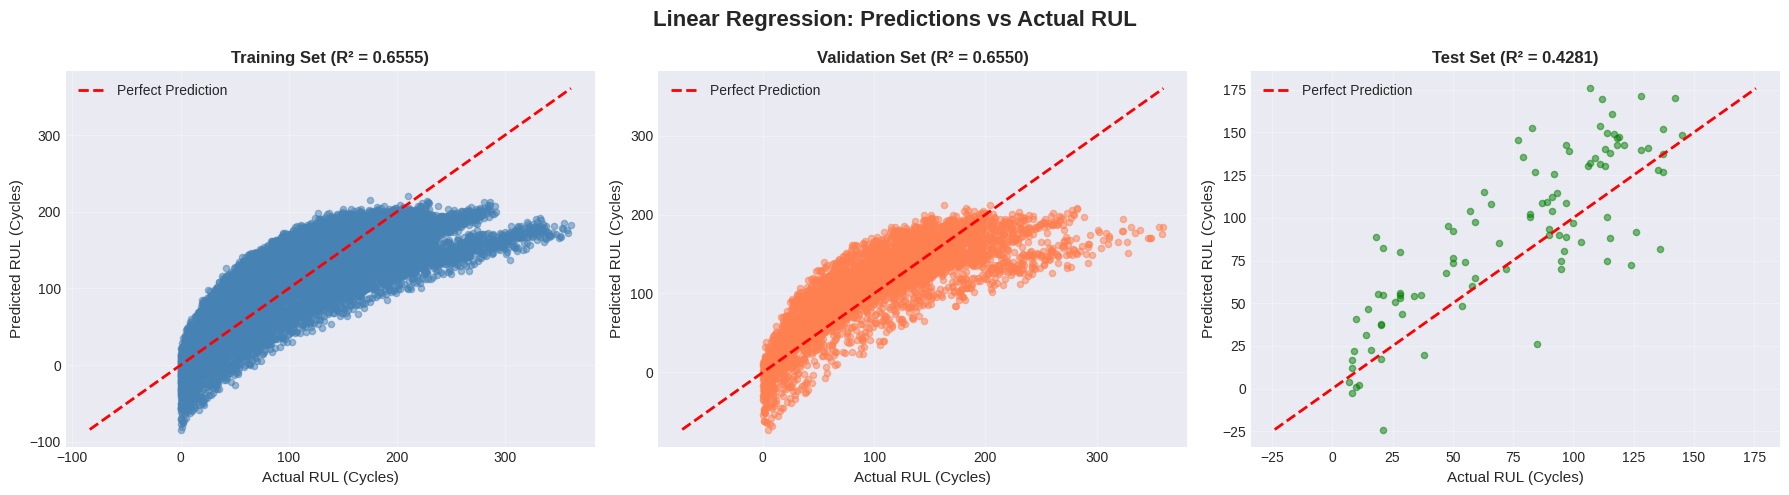

✅ Visualization created!

💡 Interpretation:
   - Points on the red line = perfect predictions
   - Points above the line = over-prediction (predicted higher than actual)
   - Points below the line = under-prediction (predicted lower than actual)


In [20]:
# Create visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression: Predictions vs Actual RUL', fontsize=16, fontweight='bold')

# Training set
axes[0].scatter(y_train_split, y_train_pred, alpha=0.5, s=20, color='steelblue')
min_val = min(min(y_train_split), min(y_train_pred))
max_val = max(max(y_train_split), max(y_train_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val_split, y_val_pred, alpha=0.5, s=20, color='coral')
min_val = min(min(y_val_split), min(y_val_pred))
max_val = max(max(y_val_split), max(y_val_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[1].set_title(f'Validation Set (R² = {val_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='green')
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[2].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualization created!")
print("\n💡 Interpretation:")
print("   - Points on the red line = perfect predictions")
print("   - Points above the line = over-prediction (predicted higher than actual)")
print("   - Points below the line = under-prediction (predicted lower than actual)")

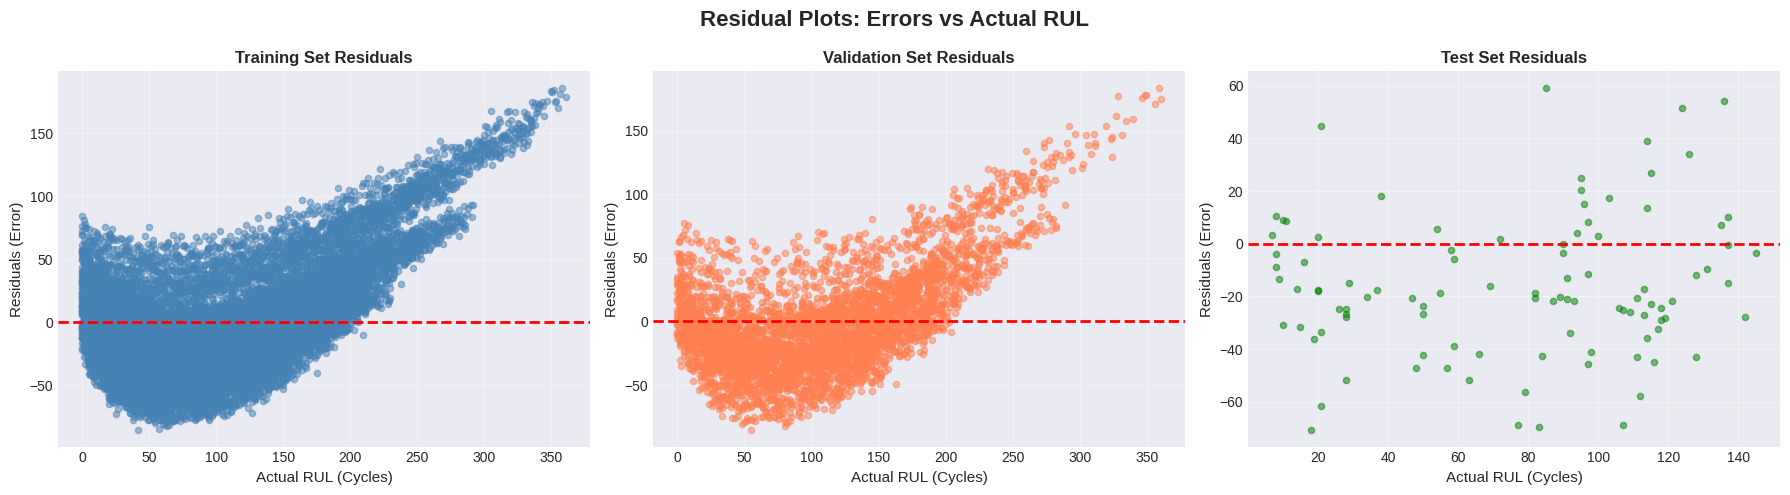

✅ Residual plots created!

💡 Interpretation:
   - Random scatter around zero = good model
   - Patterns or trends = model has systematic errors
   - Funnel shape = variance increases with RUL (heteroscedasticity)


In [21]:
# Create residual plots (errors vs actual values)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Plots: Errors vs Actual RUL', fontsize=16, fontweight='bold')

# Calculate residuals (errors)
train_residuals = y_train_split - y_train_pred
val_residuals = y_val_split - y_val_pred
test_residuals = y_test - y_test_pred

# Training set residuals
axes[0].scatter(y_train_split, train_residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Residuals (Error)', fontsize=11)
axes[0].set_title('Training Set Residuals', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Validation set residuals
axes[1].scatter(y_val_split, val_residuals, alpha=0.5, s=20, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Residuals (Error)', fontsize=11)
axes[1].set_title('Validation Set Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Test set residuals
axes[2].scatter(y_test, test_residuals, alpha=0.5, s=20, color='green')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Residuals (Error)', fontsize=11)
axes[2].set_title('Test Set Residuals', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Residual plots created!")
print("\n💡 Interpretation:")
print("   - Random scatter around zero = good model")
print("   - Patterns or trends = model has systematic errors")
print("   - Funnel shape = variance increases with RUL (heteroscedasticity)")

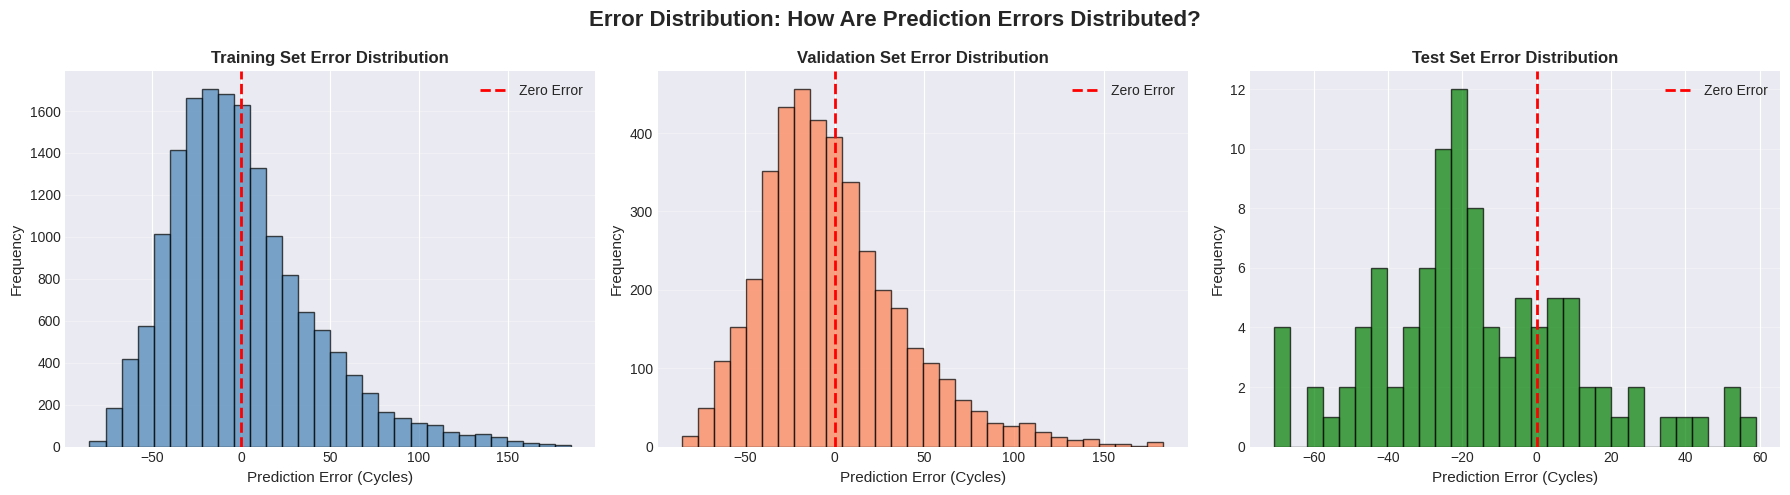

✅ Error distribution plots created!

💡 Interpretation:
   - Centered around zero = good (no systematic bias)
   - Normal distribution = good (random errors)
   - Mean error (training): 0.00 cycles
   - Mean error (test): -16.19 cycles


In [22]:
# Create error distribution histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Distribution: How Are Prediction Errors Distributed?', fontsize=16, fontweight='bold')

# Training set error distribution
axes[0].hist(train_residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Prediction Error (Cycles)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Training Set Error Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Validation set error distribution
axes[1].hist(val_residuals, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error (Cycles)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Validation Set Error Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Test set error distribution
axes[2].hist(test_residuals, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[2].set_xlabel('Prediction Error (Cycles)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Test Set Error Distribution', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Error distribution plots created!")
print("\n💡 Interpretation:")
print("   - Centered around zero = good (no systematic bias)")
print("   - Normal distribution = good (random errors)")
print(f"   - Mean error (training): {train_residuals.mean():.2f} cycles")
print(f"   - Mean error (test): {test_residuals.mean():.2f} cycles")

## Step 13: Understanding the Model Equation

Let's examine what the model actually learned. The linear regression model has created a formula that predicts RUL.

### The Learned Equation:

```
RUL = intercept + (coef₁ × feature₁) + (coef₂ × feature₂) + ... + (coefₙ × featureₙ)
```

Each coefficient tells us:
- **How much** RUL changes when that feature changes by 1 unit
- **Direction**: Positive = increases RUL, Negative = decreases RUL

### Interpreting Coefficients:

Example: If `T30` has coefficient = -2.5:
- When T30 increases by 1 unit, RUL decreases by 2.5 cycles
- Higher temperature = less remaining life (makes sense!)

Example: If `time` has coefficient = -0.1:
- As time increases by 1 cycle, RUL decreases by 0.1 cycles
- This makes sense - as engines run longer, RUL decreases

In [23]:
# Display the full model equation
print("📐 Linear Regression Model Equation:")
print("=" * 80)
print(f"\nRUL = {model.intercept_:.4f}", end="")

# Show first 5 and last 5 features
for i in range(min(5, len(feature_columns))):
    sign = "+" if model.coef_[i] >= 0 else ""
    print(f" {sign}{model.coef_[i]:.4f}×{feature_columns[i]}", end="")

print(" + ... ", end="")

for i in range(max(0, len(feature_columns)-5), len(feature_columns)):
    sign = "+" if model.coef_[i] >= 0 else ""
    print(f" {sign}{model.coef_[i]:.4f}×{feature_columns[i]}", end="")

print("\n")
print("\n💡 This equation is what the model uses to make predictions!")

📐 Linear Regression Model Equation:

RUL = 108.0316 -0.0271×Altitude +0.9018×Mach +0.0000×TRA +0.0000×T2 -2.8603×T24 + ...  +0.0000×Nf_dmd +0.0000×PCNfR_dmd +2.1830×W31 +2.5357×W32 -27.2273×time


💡 This equation is what the model uses to make predictions!


## Step 14: Feature Importance Visualization

Let's visualize which features are most important for predicting RUL.

### Why This Matters:
- Helps understand what drives RUL predictions
- Can guide feature engineering
- Identifies which sensors are most critical

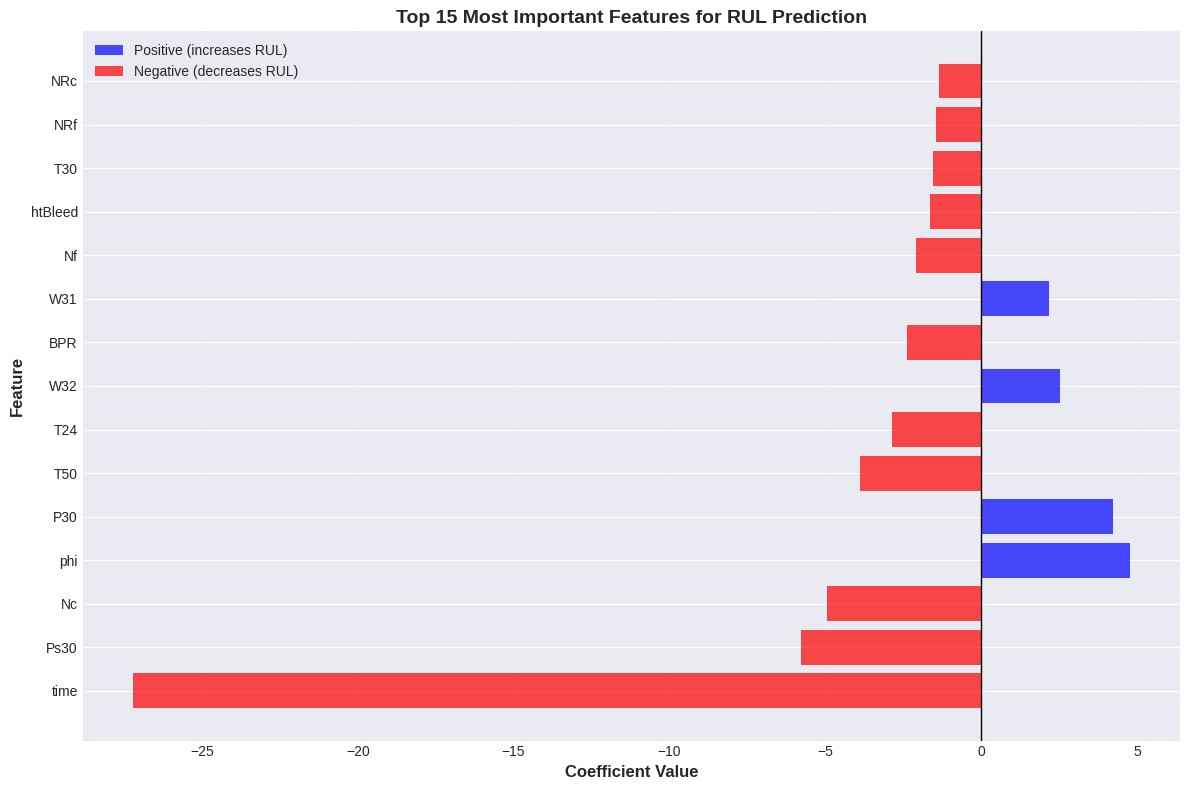

✅ Feature importance visualization created!

💡 Interpretation:
   - Blue bars: Feature increases RUL (positive coefficient)
   - Red bars: Feature decreases RUL (negative coefficient)
   - Longer bars = stronger influence on RUL prediction


In [24]:
# Visualize top 15 most important features
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features for RUL Prediction', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Positive (increases RUL)'),
    Patch(facecolor='red', alpha=0.7, label='Negative (decreases RUL)')
]
plt.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

print("✅ Feature importance visualization created!")
print("\n💡 Interpretation:")
print("   - Blue bars: Feature increases RUL (positive coefficient)")
print("   - Red bars: Feature decreases RUL (negative coefficient)")
print("   - Longer bars = stronger influence on RUL prediction")

## 🎓 Summary and Key Takeaways

Congratulations! You've successfully built and evaluated a Linear Regression model!

### ✅ What You've Learned:

1. **Linear Regression Basics**:
   - Simple but powerful algorithm
   - Predicts continuous values (regression)
   - Formula: y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

2. **Data Preparation**:
   - Separated features (X) and target (y)
   - Scaled/normalized data for better performance
   - Split data into train/validation/test sets

3. **Loss Functions**:
   - **MSE**: Mean Squared Error (squared errors)
   - **MAE**: Mean Absolute Error (absolute errors)
   - **RMSE**: Root Mean Squared Error (interpretable)
   - Linear regression minimizes MSE

4. **Model Training**:
   - Created and trained a LinearRegression model
   - Model learned weights (coefficients) and bias (intercept)
   - Used scikit-learn's efficient OLS method

5. **Evaluation**:
   - Calculated RMSE, MAE, and R² score
   - Visualized predictions vs actual values
   - Analyzed residuals and error distributions
   - Examined feature importance

### 📚 Key Concepts:

- **Features (X)**: Input variables used for prediction
- **Target (y)**: What we want to predict (RUL)
- **Loss Function**: Measures prediction error
- **Coefficients**: Learned weights for each feature
- **Overfitting**: Model memorizes training data, fails on new data
- **Generalization**: Model works well on unseen data

### 🚀 Next Steps:

Now that you understand linear regression, you can:

1. **Improve the Model**:
   - Try feature engineering (create new features)
   - Remove less important features
   - Try polynomial features (non-linear relationships)

2. **Try Other Models**:
   - Ridge Regression (L2 regularization)
   - Lasso Regression (L1 regularization)
   - Random Forest
   - Neural Networks

3. **Advanced Techniques**:
   - Cross-validation
   - Hyperparameter tuning
   - Ensemble methods

### 💡 Remember:

- Linear regression is a great **baseline** model
- Always evaluate on **unseen test data**
- **Visualize** your results to understand the model
- **Interpret** coefficients to understand what the model learned

---

**Great job completing this tutorial! 🎉📊**

## 📝 Practice Exercises

Try these exercises to reinforce your learning:

1. **Try different feature sets**:
   - Use only temperature sensors
   - Use only pressure sensors
   - Compare performance

2. **Experiment with scaling**:
   - Try `MinMaxScaler` instead of `StandardScaler`
   - Try no scaling at all
   - Compare results

3. **Analyze errors**:
   - Find engines with largest prediction errors
   - Investigate why those predictions were wrong

4. **Feature engineering**:
   - Create new features (e.g., temperature ratios)
   - Add polynomial features
   - See if performance improves

5. **Try other datasets**:
   - Train on FD002, FD003, or FD004
   - Compare model performance across datasets

Good luck! 🎯